In [ ]:
# install libraries

%pip install pandas
%pip install scikit-learn
%pip install numpy
%pip install torch

In [ ]:
# =====================================================
# PATIENT OUTCOME ANALYTICS
# =====================================================

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler


# load master dataset
DATA_PATH = "/content/drive/MyDrive/synthetic_mimic"

print("Loading master dataset...")

master = pd.read_csv(
    f"{DATA_PATH}/master_dataset.csv"
)

print("Dataset loaded successfully.")
print()

print("Dataset Shape")
print(master.shape)

print()
print("Dataset Preview")
print(master.head())

print(master.columns.tolist())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading master dataset...
Dataset loaded successfully.

Dataset Shape
(25059, 35)

Dataset Preview
   hadm_id  subject_id   admittime   dischtime  los_days admission_type  \
0   200000      100000  2022-01-06  2022-01-23        17         URGENT   
1   200001      100000  2019-11-08  2019-11-20        12       ELECTIVE   
2   200002      100000  2023-09-04  2023-09-23        19       ELECTIVE   
3   200003      100000  2023-06-14  2023-06-28        14         URGENT   
4   200004      100001  2019-08-15  2019-08-23         8    OBSERVATION   

  discharge_location  anchor_age gender      race  ...  CHF  CKD  COPD  \
0            EXPIRED          69      M     ASIAN  ...    0    0     1   
1               HOME          69      M     ASIAN  ...    0    0     1   
2              REHAB          69      M     ASIAN  ...    0    0     1   
3            EXPIRED     

In [ ]:
# research question
print(
    """
Which patient characteristics
are associated with poor outcomes
such as mortality, readmission,
sepsis, and ventilation?
"""
)


Which patient characteristics
are associated with poor outcomes
such as mortality, readmission,
sepsis, and ventilation?




90-Day Mortality Rate: 0.08372241510036314

30-Day Readmission Rate:0.14860928209425756

Sepsis Rate: 0.12043577157907338

Ventilation Rate: 0.08096891336445987

           mortality_90d    sepsis  ventilation   los_days
age_group                                                 
18-40           0.080635  0.118440     0.076669   9.937475
41-60           0.085113  0.124110     0.085113  10.034355
61-80           0.086541  0.122310     0.080782  10.059109
80+             0.082770  0.115697     0.082544   9.984438


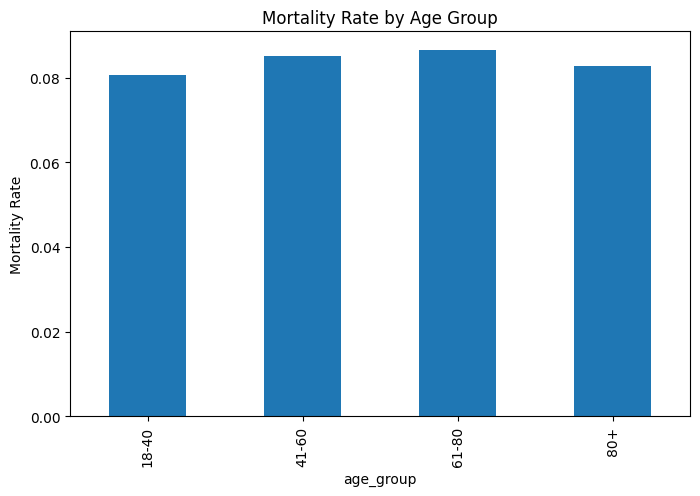

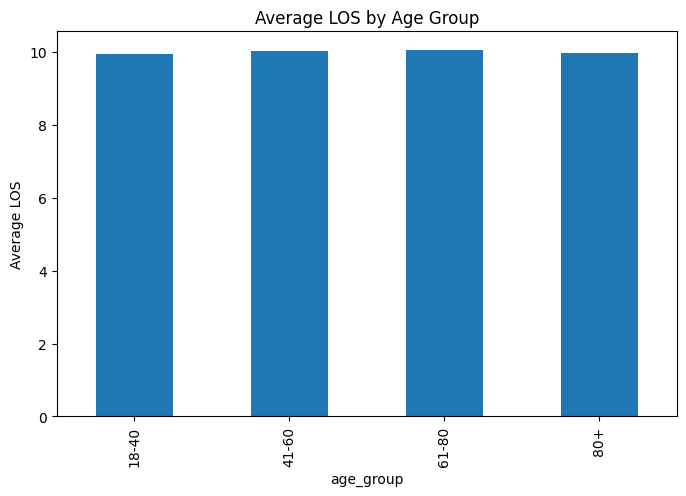


Number of Numeric Columns: 28

Correlation Matrix Created

Top Correlations With Mortality
mortality_90d            1.000000
los_days                 0.166417
long_stay                0.146039
mortality                0.029316
icu_los                  0.015797
sofa                     0.007531
sepsis                   0.005899
subject_id               0.005458
hadm_id                  0.005453
Diabetes                 0.005406
resource_score           0.005344
num_labs                 0.004988
num_medications          0.004521
anchor_age               0.004520
COPD                     0.003657
high_resource_patient    0.001204
ventilation              0.000595
readmit_30d              0.000493
CKD                     -0.000216
num_diagnoses           -0.000844
Name: mortality_90d, dtype: float64

Creating Correlation Plot...


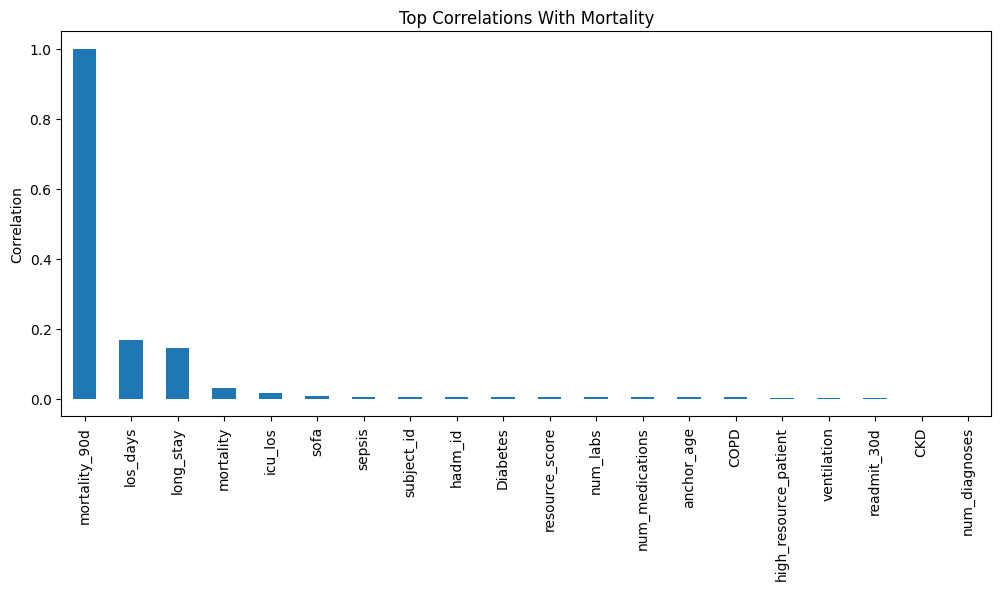


SOFA Mortality Table: sofa
0    0.071791
1    0.083682
2    0.073941
3    0.087977
4    0.082410
Name: mortality_90d, dtype: float64


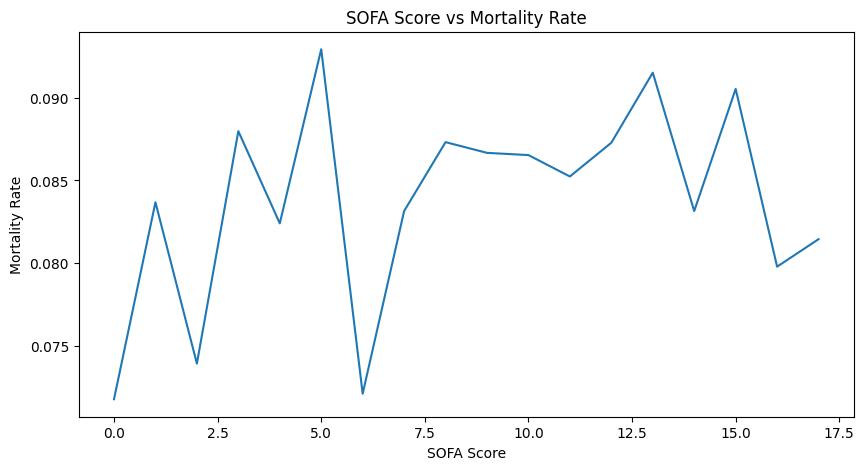


Charlson Mortality Table: charlson_index
0.8    0.089167
1.6    0.076118
2.4    0.085363
3.2    0.082456
4.0    0.085358
Name: mortality_90d, dtype: float64


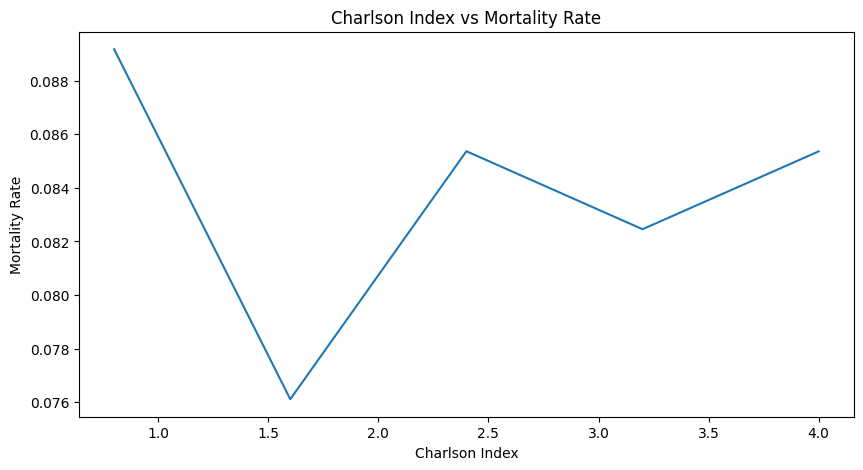

In [ ]:
# analysis
# =====================================================

# outcome analysis
# 90 day mortality
mortality_90d = master[
    "mortality_90d"
].mean()

print()
print("90-Day Mortality Rate: " + str(mortality_90d))


# readmission
readmission_rate = master[
    "readmit_30d"
].mean()

print()
print("30-Day Readmission Rate:" + str(readmission_rate))


# sepsis rate
sepsis_rate = master[
    "sepsis"
].mean()

print()
print("Sepsis Rate: " + str(sepsis_rate))


# ventilation rate
ventilation_rate = master[
    "ventilation"
].mean()

print()
print("Ventilation Rate: " + str(ventilation_rate))


# outcomes by age group
age_outcomes = master.groupby(
    "age_group"
).agg({
    "mortality_90d":"mean",
    "sepsis":"mean",
    "ventilation":"mean",
    "los_days":"mean"
})

print()
print(age_outcomes)


# plot
# age group mortality
plt.figure(figsize=(8,5))

age_outcomes[
    "mortality_90d"
].plot(
    kind="bar"
)

plt.title(
    "Mortality Rate by Age Group"
)

plt.ylabel(
    "Mortality Rate"
)

plt.show()

# age group los
plt.figure(figsize=(8,5))

age_outcomes[
    "los_days"
].plot(
    kind="bar"
)

plt.title(
    "Average LOS by Age Group"
)

plt.ylabel(
    "Average LOS"
)

plt.show()


# correlation analysis
# select numeric columns
numeric_columns = master.select_dtypes(
    include=np.number
).columns

print()
print("Number of Numeric Columns: " + str(len(numeric_columns)))

# create correlation matrix
correlation_matrix = master[
    numeric_columns
].corr()

print()
print("Correlation Matrix Created")


# correlations with mortality
print()
print("Top Correlations With Mortality")

mortality_correlations = correlation_matrix[
    "mortality_90d"
]

mortality_correlations = mortality_correlations.sort_values(
    ascending=False
)

top_mortality_correlations = (
    mortality_correlations.head(20)
)

print(top_mortality_correlations)


# visualize top correlations
print()
print("Creating Correlation Plot...")

top_mortality_correlations.plot(
    kind="bar",
    figsize=(12,5)
)

plt.title(
    "Top Correlations With Mortality"
)

plt.ylabel(
    "Correlation"
)

plt.show()

# SOFA score analysis
# higher SOFA scores generally indicate more severe illness
sofa_mortality = master.groupby(
    "sofa"
)["mortality_90d"].mean()

print()
print("SOFA Mortality Table: " + str(sofa_mortality.head()))

# plot
plt.figure(figsize=(10,5))

plt.plot(
    sofa_mortality.index,
    sofa_mortality.values
)

plt.title(
    "SOFA Score vs Mortality Rate"
)

plt.xlabel("SOFA Score")

plt.ylabel("Mortality Rate")

plt.show()


# charlson index analysis
charlson_mortality = master.groupby(
    "charlson_index"
)["mortality_90d"].mean()

print()
print("Charlson Mortality Table: " + str(charlson_mortality.head()))

# plot
plt.figure(figsize=(10,5))

plt.plot(
    charlson_mortality.index,
    charlson_mortality.values
)

plt.title(
    "Charlson Index vs Mortality Rate"
)

plt.xlabel(
    "Charlson Index"
)

plt.ylabel(
    "Mortality Rate"
)

plt.show()

In [ ]:
# select features
# =====================================================

# these variables will be used to predict mortality
features = [
    "anchor_age",
    "charlson_index",
    "sofa",
    "num_diagnoses",
    "num_medications",
    "num_labs",
    "resource_score",
    "icu_los",
    "los_days"
]

print()
print("Features Used: ")

for feature in features:
    print(feature)

# create feature matrix
X = master[features]

# target variable
y = master["mortality_90d"]

print()
print("Feature Matrix Shape: " + str(X.shape))
print()
print("Target Shape: " + str(y.shape))


Features Used: 
anchor_age
charlson_index
sofa
num_diagnoses
num_medications
num_labs
resource_score
icu_los
los_days

Feature Matrix Shape: (25059, 9)

Target Shape: (25059,)


In [ ]:
# train test split
# =====================================================

# keep 20% of data for testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print()
print("Training Rows: " + str(len(X_train)))
print()
print("Testing Rows: " + str(len(X_test)))


Training Rows: 20047

Testing Rows: 5012


In [ ]:
# logistic regression model
# =====================================================

# create the model
logistic_model = LogisticRegression(
    max_iter=5000
)

print("Model created.")

# train the model
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logistic_model.fit(
    X_train_scaled,
    y_train
)

print("Training complete.")

# make predictions
logistic_predictions = logistic_model.predict(
    X_test
)

# probability scores are needed for ROC auc
logistic_probabilities = logistic_model.predict_proba(
    X_test
)

# keep only probability of mortality
logistic_probabilities = logistic_probabilities[:,1]


# logistic regression eval.
report = classification_report(
    y_test,
    logistic_predictions
)

print(report)

# precision
logistic_precision = precision_score(
    y_test,
    logistic_predictions
)

print()
print("Precision: " + str(logistic_precision))

# recall
logistic_recall = recall_score(
    y_test,
    logistic_predictions
)

print()
print("Recall: " + str(logistic_recall))

# f1 score
logistic_f1 = f1_score(
    y_test,
    logistic_predictions
)

print()
print("F1 Score: " + str(logistic_f1))

# roc auc
logistic_auc = roc_auc_score(
    y_test,
    logistic_probabilities
)

print()
print("ROC AUC: " + str(logistic_auc))

Model created.
Training complete.
              precision    recall  f1-score   support

           0       0.98      0.11      0.20      4592
           1       0.09      0.98      0.17       420

    accuracy                           0.18      5012
   macro avg       0.54      0.55      0.18      5012
weighted avg       0.91      0.18      0.19      5012


Precision: 0.09155555555555556

Recall: 0.9809523809523809

F1 Score: 0.16747967479674797

ROC AUC: 0.6600137921022068


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


[[ 504 4088]
 [   8  412]]


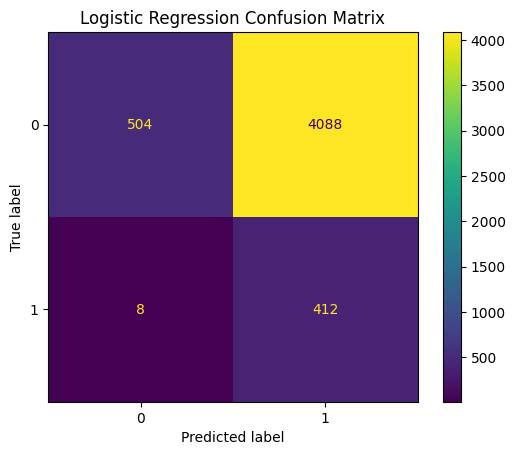

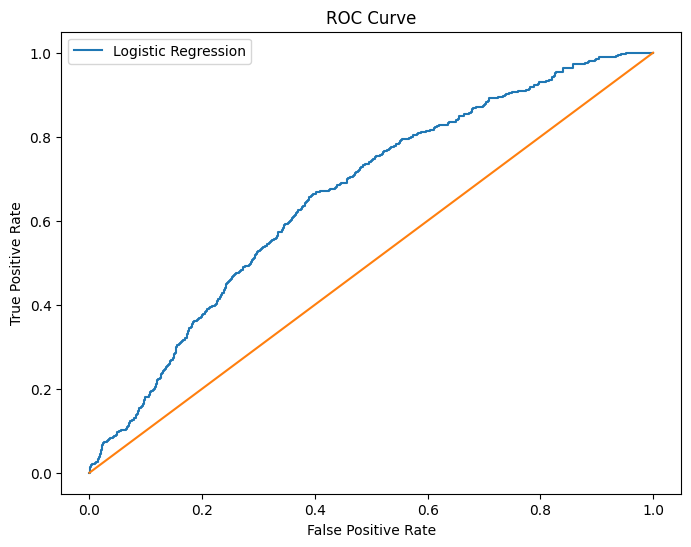

In [ ]:
# confusion matrix
logistic_cm = confusion_matrix(
    y_test,
    logistic_predictions
)

print(logistic_cm)

ConfusionMatrixDisplay(
    confusion_matrix=logistic_cm
).plot()

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.show()


# ROC curve
false_positive_rate, true_positive_rate, thresholds = roc_curve(
    y_test,
    logistic_probabilities
)

plt.figure(figsize=(8,6))

plt.plot(
    false_positive_rate,
    true_positive_rate,
    label="Logistic Regression"
)

# diagonal reference line
plt.plot(
    [0,1],
    [0,1]
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve"
)

plt.legend()

plt.show()

           Feature  Coefficient
8         los_days     0.662710
7          icu_los     0.055497
2             sofa     0.018606
5         num_labs     0.013932
4  num_medications     0.006374
0       anchor_age     0.005952
6   resource_score     0.001339
3    num_diagnoses    -0.006060
1   charlson_index    -0.006060


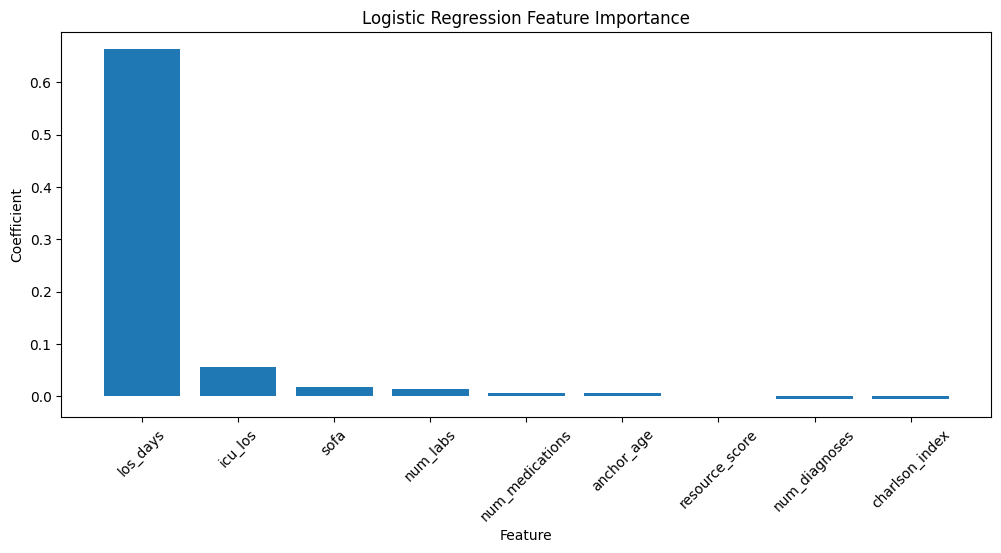

In [ ]:
# logistic regression feature importance
# =====================================================

# coefficients tell  which features increase or decrease mortality risk
logistic_importance = pd.DataFrame()

logistic_importance["Feature"] = features

logistic_importance["Coefficient"] = (
    logistic_model.coef_[0]
)

logistic_importance = logistic_importance.sort_values(
    by="Coefficient",
    ascending=False
)

print(logistic_importance)

# plot feature importance
plt.figure(figsize=(12,5))

plt.bar(
    logistic_importance["Feature"],
    logistic_importance["Coefficient"]
)

plt.title(
    "Logistic Regression Feature Importance"
)

plt.xlabel(
    "Feature"
)

plt.ylabel(
    "Coefficient"
)

plt.xticks(rotation=45)

plt.show()

Model created.
Training complete.
              precision    recall  f1-score   support

           0       0.92      1.00      0.96      4592
           1       0.00      0.00      0.00       420

    accuracy                           0.92      5012
   macro avg       0.46      0.50      0.48      5012
weighted avg       0.84      0.92      0.88      5012


Precision: 0.0

Recall: 0.0

F1 Score: 0.0

ROC AUC: 0.6082101895636304
           Feature  Importance
7          icu_los    0.222925
0       anchor_age    0.172352
2             sofa    0.120856
6   resource_score    0.112654
8         los_days    0.111650
5         num_labs    0.103743
4  num_medications    0.075861
3    num_diagnoses    0.040033
1   charlson_index    0.039926


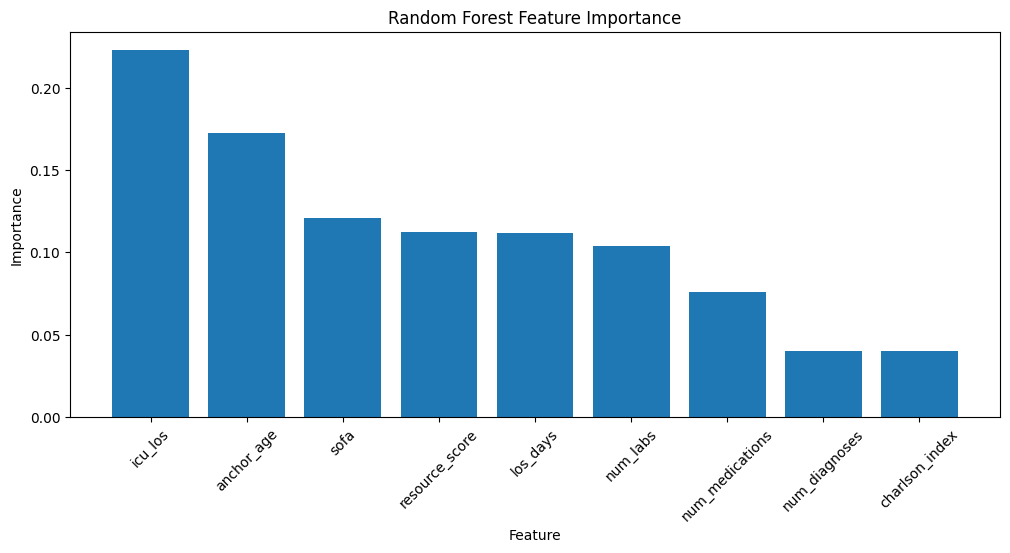

In [ ]:
# random forest model
# =====================================================

# random forest uses many decision trees
random_forest = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

print("Model created.")

# train the model
random_forest.fit(
    X_train,
    y_train
)

print("Training complete.")

# predictions
rf_predictions = random_forest.predict(
    X_test
)

# probabilities
rf_probabilities = random_forest.predict_proba(
    X_test
)

rf_probabilities = rf_probabilities[:,1]


# random forest evalution
rf_report = classification_report(
    y_test,
    rf_predictions
)

print(rf_report)

# precision
rf_precision = precision_score(
    y_test,
    rf_predictions
)

print()
print("Precision: " + str(rf_precision))


# recall
rf_recall = recall_score(
    y_test,
    rf_predictions
)

print()
print("Recall: " + str(rf_recall))


# f1 score
rf_f1 = f1_score(
    y_test,
    rf_predictions
)

print()
print("F1 Score: " + str(rf_f1))


# roc auc
rf_auc = roc_auc_score(
    y_test,
    rf_probabilities
)

print()
print("ROC AUC: " + str(rf_auc))


# random forest feature importance
rf_importance = pd.DataFrame()

rf_importance["Feature"] = features

rf_importance["Importance"] = (
    random_forest.feature_importances_
)

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

print(rf_importance)

# plot importance
plt.figure(figsize=(12,5))

plt.bar(
    rf_importance["Feature"],
    rf_importance["Importance"]
)

plt.title(
    "Random Forest Feature Importance"
)

plt.xlabel(
    "Feature"
)

plt.ylabel(
    "Importance"
)

plt.xticks(rotation=45)

plt.show()

In [ ]:
# model comparison
comparison = pd.DataFrame({

    "Metric":[
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],

    "Logistic Regression":[
        logistic_precision,
        logistic_recall,
        logistic_f1,
        logistic_auc
    ],

    "Random Forest":[
        rf_precision,
        rf_recall,
        rf_f1,
        rf_auc
    ]

})

print(comparison)


# top risk factors
print()

print(
    rf_importance.head(10)
)

      Metric  Logistic Regression  Random Forest
0  Precision             0.091556        0.00000
1     Recall             0.980952        0.00000
2   F1 Score             0.167480        0.00000
3    ROC AUC             0.660014        0.60821

           Feature  Importance
7          icu_los    0.222925
0       anchor_age    0.172352
2             sofa    0.120856
6   resource_score    0.112654
8         los_days    0.111650
5         num_labs    0.103743
4  num_medications    0.075861
3    num_diagnoses    0.040033
1   charlson_index    0.039926


In [ ]:
# exporting results
# =====================================================

rf_importance.to_csv(
    f"{DATA_PATH}/rf_feature_importance.csv",
    index=False
)

logistic_importance.to_csv(
    f"{DATA_PATH}/logistic_feature_importance.csv",
    index=False
)

comparison.to_csv(
    f"{DATA_PATH}/model_comparison.csv",
    index=False
)

print()
print("Files saved successfully.")


# project summary
print()

print("Logistic Regression ROC AUC:")
print(logistic_auc)

print()

print("Random Forest ROC AUC:")
print(rf_auc)

print()

if rf_auc > logistic_auc:

    print(
        "Random Forest performed better."
    )

else:

    print(
        "Logistic Regression performed better."
    )

print()
print("Analysis complete.")


Files saved successfully.

Logistic Regression ROC AUC:
0.6600137921022068

Random Forest ROC AUC:
0.6082101895636304

Logistic Regression performed better.

Analysis complete.
